# ICML 2025 Reproduction

This notebook starts with a short reproduction of the pruning recipe in the paper, then reproduces the results of the paper. 

## Pruning recipe

We first expose the pruning implementation based on the path-magnitudes (Section 5.2 of the paper), 
and the random rescaling method used to test robustness of *standard* pruning (Section 5.4 of the paper). 

The code for both of these is in `repro/icml25/utils/rescaling.py`, `repro/icml25/utils/path_magnitude.py`, and `repro/icml25/utils/pipeline.py`.


In [11]:

import numpy as np
import torch
import torchvision.models as models

from repro.icml25.utils.path_magnitude import apply_path_magnitude_pruning
from repro.icml25.utils.pipeline import iter_prunable_modules
from repro.icml25.utils.rescaling import DEFAULT_RESCALE_FACTORS, random_rescale_resnet18

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

resnet18 = models.resnet18(weights=None).to(DEVICE).eval()
x = torch.randn(1, 3, 224, 224, device=DEVICE)

with torch.no_grad():
    y_before = resnet18(x)

# Same neuron-wise rescaling used in repro/icml25/utils/rescaling.py.
random_rescale_resnet18(resnet18, rng=np.random.default_rng(0))

with torch.no_grad():
    y_after = resnet18(x)

# The rescaling preserves the network function up to numerical precision.
print('Random rescaling factors:', DEFAULT_RESCALE_FACTORS) # with powers of 2, rescaling leads to exact numerical equivalence if precision allows
print('max |f(x) before - f(x) after rescaling| =', float((y_before - y_after).abs().max()), ' (should be close to 0, up to numerical precision, and exactly 0 with powers of 2 rescaling factors)')

# Same pruning wrapper used by repro/icml25/utils/pipeline.py.
apply_path_magnitude_pruning(
    resnet18,
    amount=0.4,
    input_shape=(1, 3, 224, 224),
    device=DEVICE,
)

total_params = 0
zero_params = 0
for module, name in iter_prunable_modules(resnet18):
    weight = getattr(module, name)
    total_params += weight.numel()
    zero_params += int((weight == 0).sum().item())

print('global sparsity after path-magnitude pruning:', round(100 * zero_params / total_params, 1), '%')


Random rescaling factors: (1, 128, 4096)
max |f(x) before - f(x) after rescaling| = 0.0  (should be close to 0, up to numerical precision, and exactly 0 with powers of 2 rescaling factors)
global sparsity after path-magnitude pruning: 40.0 %


# Results reproduction

The rest of the notebook is dedicated to reproducing the results in the paper, in the same order as they appear in it. 

By default it reads the included results from `repro/icml25/results/paper_release/`. The included pruning results use one seed. To inspect your own reruns, change `RESULTS_SOURCE` in the next cell to `rerun`.

In [2]:
import base64
from html import escape
from pathlib import Path
import os
import sys

from IPython.display import HTML, Markdown, display

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from repro.icml25.utils.imagenet_data import check_imagenet_prepared
from repro.icml25.utils.results import (
    format_accuracy_table,
    format_dense_summary,
    format_runtime_summary,
    load_body_accuracy_table,
    load_dense_summary,
    load_full_accuracy_table,
    load_runtime_summary,
    load_training_curve_figure_path,
    load_training_curves,
)
from repro.icml25.utils.plot_training_curves import save_training_curves_figure
from repro.icml25.utils.workflow import (
    accuracy_sweep_command,
    dense_train_command,
    full_repro_command,
    icml25_wrapper_script,
    require_imagenet,
    run_command,
    runtime_benchmark_command,
)

ICML25_ROOT = REPO_ROOT / 'repro' / 'icml25'
ICML25_RESULTS_ROOT = ICML25_ROOT / 'results'
PAPER_RESULTS_ROOT = ICML25_RESULTS_ROOT / 'paper_release'
RERUN_RESULTS_ROOT = ICML25_RESULTS_ROOT / 'rerun'
IMAGENET_DIR = Path(os.environ.get('IMAGENET_DIR', REPO_ROOT / 'data' / 'imagenet'))
RERUN_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

LIGHTWEIGHT_SEEDS = (1,)
FULL_SCALE_SEEDS = (1, 2, 3)
RESULTS_SOURCE = 'paper_release'  # Change to 'rerun' to inspect your own reruns.
RUN_FULL_REPRO = False
RUN_RUNTIME_BENCHMARK = False
RUN_DENSE_TRAIN = False
RUN_ACCURACY_SWEEP = False
ALLOW_INTERACTIVE_LONG_RERUN = False

if RESULTS_SOURCE not in {'paper_release', 'rerun'}:
    raise ValueError("RESULTS_SOURCE must be 'paper_release' or 'rerun'.")

if RUN_FULL_REPRO:
    RUN_RUNTIME_BENCHMARK = True
    RUN_DENSE_TRAIN = True
    RUN_ACCURACY_SWEEP = True

def repo_relative_path(path):
    path = Path(path)
    try:
        return path.resolve().relative_to(REPO_ROOT.resolve()).as_posix()
    except Exception:
        try:
            return path.relative_to(REPO_ROOT).as_posix()
        except Exception:
            return path.as_posix()


def display_command_block(title, command):
    display(Markdown(f"**{title}**\n```bash\n{command}\n```"))


def display_saved_figure(path):
    path = Path(path)
    preview_path = path.with_suffix('.png')
    rel_path = escape(repo_relative_path(path))
    if preview_path.exists():
        encoded_png = base64.b64encode(preview_path.read_bytes()).decode('ascii')
        display(HTML(
            "<div style='max-width: 980px;'>"
            f"<img src='data:image/png;base64,{encoded_png}' style='width:100%; border:1px solid #ddd; background:#fff;' />"
            f"<div style='margin-top: 6px; color: #666; font-family: monospace; font-size: 12px;'>{rel_path}</div>"
            "</div>"
        ))
    else:
        display(Markdown(f"Saved figure: `{repo_relative_path(path)}`"))


imagenet_status = check_imagenet_prepared(IMAGENET_DIR)
print('device:', DEVICE)
print('included results:', repo_relative_path(PAPER_RESULTS_ROOT))
print('rerun results:', repo_relative_path(RERUN_RESULTS_ROOT))
print('results source:', 'included results' if RESULTS_SOURCE == 'paper_release' else 'rerun')
print('ImageNet status:', 'ready' if imagenet_status.prepared else 'not ready')


device: cuda
included results: repro/icml25/results/paper_release
rerun results: repro/icml25/results/rerun
results source: included results
ImageNet status: ready


## Table 3: runtime comparison


In [3]:
if RUN_RUNTIME_BENCHMARK:
    run_command(
        ['bash', str(icml25_wrapper_script(REPO_ROOT, 'run_runtime_benchmark.sh'))],
        repo_root=REPO_ROOT,
        env={'RESULTS_ROOT': RERUN_RESULTS_ROOT},
    )

runtime_df = load_runtime_summary(ICML25_RESULTS_ROOT, source=RESULTS_SOURCE)
if runtime_df.empty:
    print('No benchmark_summary.csv found under the selected source.')
else:
    display(format_runtime_summary(runtime_df))

display_command_block('Command to rerun (runtime: minutes):', runtime_benchmark_command(results_root=RERUN_RESULTS_ROOT))


,Network,Forward,Magnitude,OBD,Path-Mag
0,AlexNet,1.6--8.3,4.5,16.1--45.3,25.1
1,VGG16,3.6--69.6,7.9,37.8--1510.0,86.3
2,ResNet18,3.1--16.9,1.9,74.5--231.3,49.2


**Command to rerun (runtime: minutes):**
```bash
RESULTS_ROOT="repro/icml25/results/rerun" \
bash repro/icml25/utils/run_runtime_benchmark.sh
```

## Dense ImageNet baseline

The paper uses this dense baseline as the reference accuracy for the pruning tables and the 40% fine-tuning curves.


In [4]:
if RUN_DENSE_TRAIN and not ALLOW_INTERACTIVE_LONG_RERUN:
    print('Long dense reruns stay off by default in the notebook.')
    display_command_block('Command to rerun (about 18h per seed on 1×A100-40GB): dense baseline, 1 seed', dense_train_command(IMAGENET_DIR, seeds=LIGHTWEIGHT_SEEDS, results_root=RERUN_RESULTS_ROOT))
    display_command_block('Command to rerun (about 18h per seed on 1×A100-40GB): dense baseline, 3 seeds', dense_train_command(IMAGENET_DIR, seeds=FULL_SCALE_SEEDS, results_root=RERUN_RESULTS_ROOT))
elif RUN_DENSE_TRAIN:
    require_imagenet(IMAGENET_DIR)
    run_command(
        ['bash', str(icml25_wrapper_script(REPO_ROOT, 'run_dense_train.sh'))],
        repo_root=REPO_ROOT,
        env={
            'DATA_DIR': IMAGENET_DIR,
            'SEEDS': ' '.join(str(seed) for seed in LIGHTWEIGHT_SEEDS),
            'RESULTS_ROOT': RERUN_RESULTS_ROOT,
        },
    )

dense_df = load_dense_summary(ICML25_RESULTS_ROOT, source=RESULTS_SOURCE)
if dense_df.empty:
    print('No dense_summary.csv found under the selected source.')
else:
    display(format_dense_summary(dense_df))

display_command_block('Command to rerun (about 18h per seed on 1×A100-40GB): dense baseline, 1 seed', dense_train_command(IMAGENET_DIR, seeds=LIGHTWEIGHT_SEEDS, results_root=RERUN_RESULTS_ROOT))
display_command_block('Command to rerun (about 18h per seed on 1×A100-40GB): dense baseline, 3 seeds', dense_train_command(IMAGENET_DIR, seeds=FULL_SCALE_SEEDS, results_root=RERUN_RESULTS_ROOT))


,Setting,Top-1 accuracy,Mean val top-1,Mean best epoch,Runs
0,Dense baseline,68.7,64.4,87.0,3


**Command to rerun (about 18h per seed on 1×A100-40GB): dense baseline, 1 seed**
```bash
DATA_DIR="${IMAGENET_DIR:-data/imagenet}" \
RESULTS_ROOT="repro/icml25/results/rerun" \
SEEDS="1" \
bash repro/icml25/utils/run_dense_train.sh
```

**Command to rerun (about 18h per seed on 1×A100-40GB): dense baseline, 3 seeds**
```bash
DATA_DIR="${IMAGENET_DIR:-data/imagenet}" \
RESULTS_ROOT="repro/icml25/results/rerun" \
SEEDS="1 2 3" \
bash repro/icml25/utils/run_dense_train.sh
```

## Table 4: main pruning table


In [5]:
if RUN_ACCURACY_SWEEP and not ALLOW_INTERACTIVE_LONG_RERUN:
    print('Long pruning reruns stay off by default in the notebook.')
    display_command_block('Command to rerun (multi-day offline job): pruning sweep, 1 seed', accuracy_sweep_command(IMAGENET_DIR, seeds=LIGHTWEIGHT_SEEDS, results_root=RERUN_RESULTS_ROOT))
    display_command_block('Command to rerun (large offline campaign): pruning sweep, 3 seeds', accuracy_sweep_command(IMAGENET_DIR, seeds=FULL_SCALE_SEEDS, results_root=RERUN_RESULTS_ROOT))
elif RUN_ACCURACY_SWEEP:
    require_imagenet(IMAGENET_DIR)
    run_command(
        ['bash', str(icml25_wrapper_script(REPO_ROOT, 'run_accuracy_sweep.sh'))],
        repo_root=REPO_ROOT,
        env={
            'DATA_DIR': IMAGENET_DIR,
            'SEEDS': ' '.join(str(seed) for seed in LIGHTWEIGHT_SEEDS),
            'RESULTS_ROOT': RERUN_RESULTS_ROOT,
        },
    )

body_df = load_body_accuracy_table(ICML25_RESULTS_ROOT, source=RESULTS_SOURCE)
if body_df.empty:
    print('No pruning_accuracy_body.csv found under the selected source.')
else:
    display(format_accuracy_table(body_df))

display_command_block('Command to rerun (multi-day offline job): pruning sweep, 1 seed', accuracy_sweep_command(IMAGENET_DIR, seeds=LIGHTWEIGHT_SEEDS, results_root=RERUN_RESULTS_ROOT))
display_command_block('Command to rerun (large offline campaign): pruning sweep, 3 seeds', accuracy_sweep_command(IMAGENET_DIR, seeds=FULL_SCALE_SEEDS, results_root=RERUN_RESULTS_ROOT))


,Pruning method,40%,60%,80%
0,Path-magnitude,68.9,68.4,64.9
1,Magnitude,69.2,68.6,67.3
2,Magnitude (rescaled),62.4,59.1,0.1


**Command to rerun (multi-day offline job): pruning sweep, 1 seed**
```bash
DATA_DIR="${IMAGENET_DIR:-data/imagenet}" \
RESULTS_ROOT="repro/icml25/results/rerun" \
SEEDS="1" \
bash repro/icml25/utils/run_accuracy_sweep.sh
```

**Command to rerun (large offline campaign): pruning sweep, 3 seeds**
```bash
DATA_DIR="${IMAGENET_DIR:-data/imagenet}" \
RESULTS_ROOT="repro/icml25/results/rerun" \
SEEDS="1 2 3" \
bash repro/icml25/utils/run_accuracy_sweep.sh
```

## Figure 4: 40% fine-tuning curves


Showing saved figure from repro/icml25/results/paper_release/plot_training_curves_test0.4.pdf



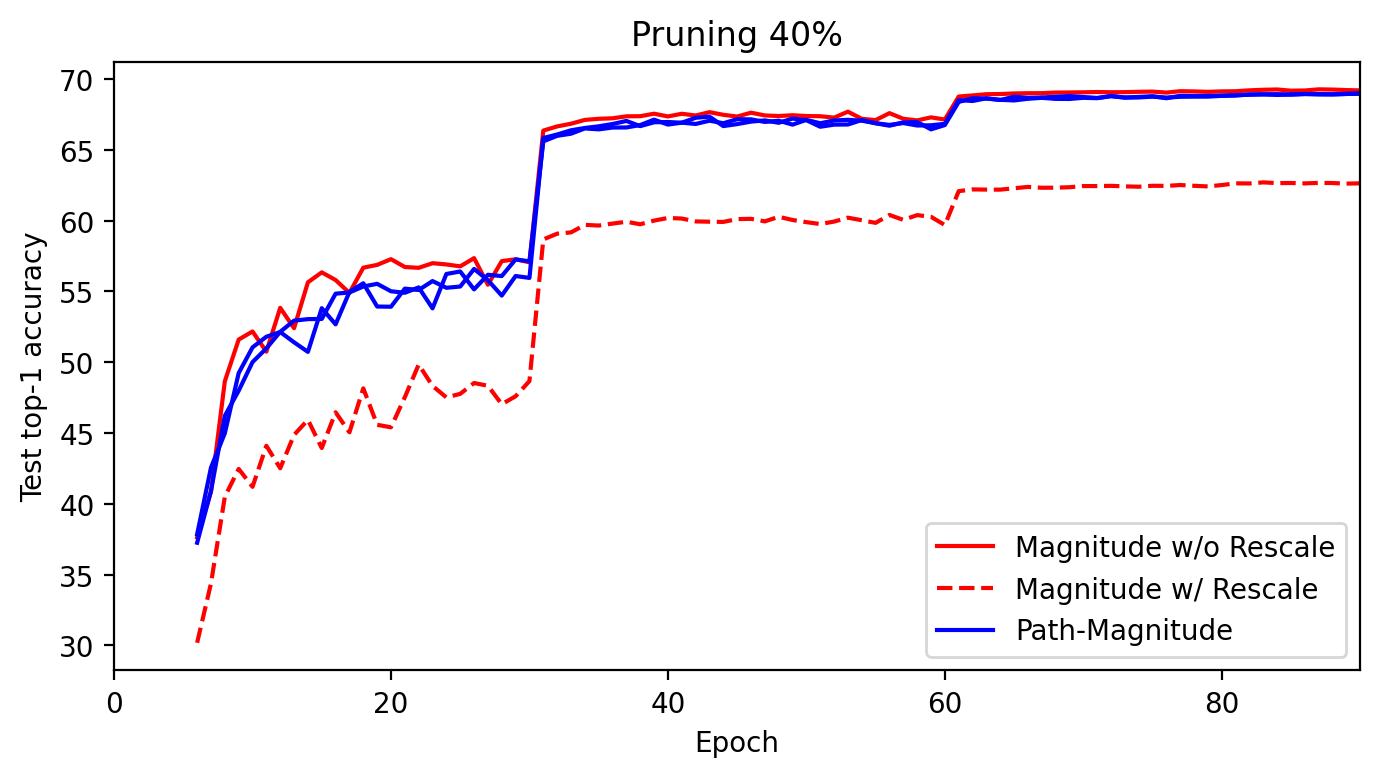

In [6]:
curve_payload = load_training_curves(ICML25_RESULTS_ROOT, source=RESULTS_SOURCE)
curve_figure_path = load_training_curve_figure_path(ICML25_RESULTS_ROOT, source=RESULTS_SOURCE)
if curve_figure_path is not None:
    print('Showing saved figure from', repo_relative_path(curve_figure_path))
    display_saved_figure(curve_figure_path)
elif curve_payload is None:
    print('No training_curves_0.4.json found under the selected source.')
else:
    generated_curve_path = Path('/tmp') / f'icml25_training_curves_0.4_{RESULTS_SOURCE}.pdf'
    save_training_curves_figure(curve_payload, generated_curve_path)
    print('Showing generated figure.')
    display_saved_figure(generated_curve_path)


## Table 5: extended pruning table


In [7]:
full_df = load_full_accuracy_table(ICML25_RESULTS_ROOT, source=RESULTS_SOURCE)
if full_df.empty:
    print('No pruning_accuracy_full.csv found under the selected source.')
else:
    display(format_accuracy_table(full_df))

display_command_block('Command to rerun all results (about 3 days on 8×A100-40GB): 1 seed', full_repro_command(IMAGENET_DIR, seeds=LIGHTWEIGHT_SEEDS, results_root=RERUN_RESULTS_ROOT))
display_command_block('Command to rerun all results (long offline campaign): 3 seeds', full_repro_command(IMAGENET_DIR, seeds=FULL_SCALE_SEEDS, results_root=RERUN_RESULTS_ROOT))


,Pruning method,none,10%,20%,40%,60%,80%
0,Path-Magnitude (*),68.7,68.7,68.7,68.9,68.4,64.9
1,Magnitude w/o Random Rescale,68.7,69.1,69.4,69.2,68.6,67.3
2,Magnitude w/ Random Rescale,68.7,68.8,68.2,62.4,59.1,0.1


**Command to rerun all results (about 3 days on 8×A100-40GB): 1 seed**
```bash
DATA_DIR="${IMAGENET_DIR:-data/imagenet}" \
RESULTS_ROOT="repro/icml25/results/rerun" \
DENSE_SEEDS="1" \
PRUNING_SEEDS="1" \
PRECHECK_SMOKE=1 \
bash repro/icml25/utils/run_campaign.sh
```

**Command to rerun all results (long offline campaign): 3 seeds**
```bash
DATA_DIR="${IMAGENET_DIR:-data/imagenet}" \
RESULTS_ROOT="repro/icml25/results/rerun" \
DENSE_SEEDS="1 2 3" \
PRUNING_SEEDS="1 2 3" \
PRECHECK_SMOKE=1 \
bash repro/icml25/utils/run_campaign.sh
```